# Doğrusal Olmayan SVM Sınıflandırma ve Çekirdek Hilesi Kernel Trick

Doğrusal ayrılamayan verilerin yüksek boyutlu uzaya taşınması, Polynomial Kernel ve RBF Kernel matematiksel yapılarının incelenmesi.

## Polynomial Kernel ve Çekirdek Hilesi

Çekirdek hilesinin - Kernel Trick - matematiksel örneği:

- **Tanımlanan 2 boyutlu noktalar:**
  $$a = \begin{bmatrix} 2 \\ 3 \end{bmatrix}, \quad b = \begin{bmatrix} 4 \\ 1 \end{bmatrix}$$

Bu verileri doğrusal ayrılabilir kılmak için 2. dereceden polinom özelliklerine dönüştüren mapping fonksiyonu $\Phi(x)$:
$$\Phi(x) = \begin{bmatrix} x_1^2 \\ \sqrt{2} x_1 x_2 \\ x_2^2 \end{bmatrix}$$

### **A**: Doğrudan Özellik Uzayına Taşımak ve Nokta Çarpımı Almak

1. **a noktasının yüksek boyuta taşınması:**
   $$\Phi(a) = \begin{bmatrix} 2^2 \\ \sqrt{2} \cdot 2 \cdot 3 \\ 3^2 \end{bmatrix} = \begin{bmatrix} 4 \\ 6\sqrt{2} \\ 9 \end{bmatrix}$$

2. **b noktasının yüksek boyuta taşınması:**
   $$\Phi(b) = \begin{bmatrix} 4^2 \\ \sqrt{2} \cdot 4 \cdot 1 \\ 1^2 \end{bmatrix} = \begin{bmatrix} 16 \\ 4\sqrt{2} \\ 1 \end{bmatrix}$$

3. **Yüksek boyuttaki bu iki vektörün nokta çarpımının hesaplanması:**
   $$\Phi(a)^T \Phi(b) = (4 \times 16) + (6\sqrt{2} \times 4\sqrt{2}) + (9 \times 1)$$
   $$\Phi(a)^T \Phi(b) = 64 + (24 \times 2) + 9 = 64 + 48 + 9 = 121$$

### **B**: Çekirdek Hilesi - Kernel Trick - Kullanmak

Aynı çarpım Polynomial Çekirdek fonksiyonu $K(a, b) = (a^T b)^2$ kullanılarak hesaplanır. Noktaları yüksek boyuta hiç taşımadan doğrudan orijinal uzayda iç çarpım işlemi gerçekleştirilir:

1. **a ve b'nin nokta çarpımının hesaplanması:**
   $$a^T b = (2 \times 4) + (3 \times 1) = 8 + 3 = 11$$

2. **Çekirdek fonksiyonunun uygulanması:**
   $$K(a, b) = (11)^2 = 121$$

**Sonuç:** Her iki yöntem de $121$ sonucunu verir. Çekirdek hilesi sayesinde yüksek boyutlu $\Phi(a)$ ve $\Phi(b)$ vektörlerini bellekte fiziksel olarak oluşturup çarpmak yerine, doğrudan orijinal uzayda $(a^Tb)^2$ formülü ile aynı sonuç çok daha hızlı elde edilir.

## Benzerlik Özellikleri ve RBF Kernel Dönüşümü

**Radial Basis Function (RBF) Kernel**, veri noktalarını sabit referans noktalarına - landmark - olan benzerliklerine göre yeni bir uzaya taşır. Benzerlik ölçümü için Gaussian RBF formülü kullanılır:

$$\phi_{\gamma}(x, \ell) = \exp\left( -\gamma \|x - \ell\|^2 \right)$$

- $x$: veri noktası, $\ell$: landmark - referans noktası.
- Mesafe sıfırsa çıktı $1$ - %100 benzerlik - olur. Nokta uzaklaştıkça çıktı $0$'a yaklaşır.

### Sayısal Landmark Örneği - 1D'den 2D'ye

Tek boyutlu doğrusal ayrılamayan bir veri kümesinde, iki adet referans noktası belirlenir:
- Landmark 1: $\ell_1 = -2$
- Landmark 2: $\ell_2 = 1$
- Yayılım katsayısı: $\gamma = 0.3$

$x = -1$ noktasının bu iki landmark benzerliğine göre yeni bir iki boyutlu koordinata taşınması:

1. **Landmark 1'e benzerlik ($x_2$):**
   $$\phi_{0.3}(-1, -2) = \exp\left(-0.3 \times |-1 - (-2)|^2\right) = \exp(-0.3 \times 1^2) = \exp(-0.3) \approx 0.74$$

2. **Landmark 2'ye benzerlik ($x_3$):**
   $$\phi_{0.3}(-1, 1) = \exp\left(-0.3 \times |-1 - 1|^2\right) = \exp(-0.3 \times 2^2) = \exp(-1.2) \approx 0.30$$

**Yeni Nokta:** Orijinalinde tek boyutlu $x = -1$ olan nokta, benzerlik uzayında iki boyutlu $[0.74, 0.30]$ noktasına dönüşür. Tüm noktalar bu şekilde taşındığında doğrusal ayrılabilir hale gelir.

## Gamma - $\gamma$ -  Hiperparametresi

Gaussian RBF kernel'daki $\gamma$ parametresi, çan eğrisinin genişliğini ve veri noktalarının etki çapını kontrol eder:
- **Yüksek $\gamma$**: Çan eğrisi daralır. Her noktanın etki alanı küçülür. Karar sınırı veri noktaları etrafında kıvrılarak karmaşıklaşır (**Overfitting** riski).
- **Düşük $\gamma$**: Çan eğrisi genişler. Noktaların etki alanı büyür. Model daha düzgün ve genelleştirilmiş bir sınır çizer. Bu da **Underfitting** riski oluşturur.

## Nonlinear SVM Sınıflandırma Uygulaması

Scikit-Learn `SVC` sınıfı kullanılarak doğrusal olmayan karar sınırlarının gösterimi.

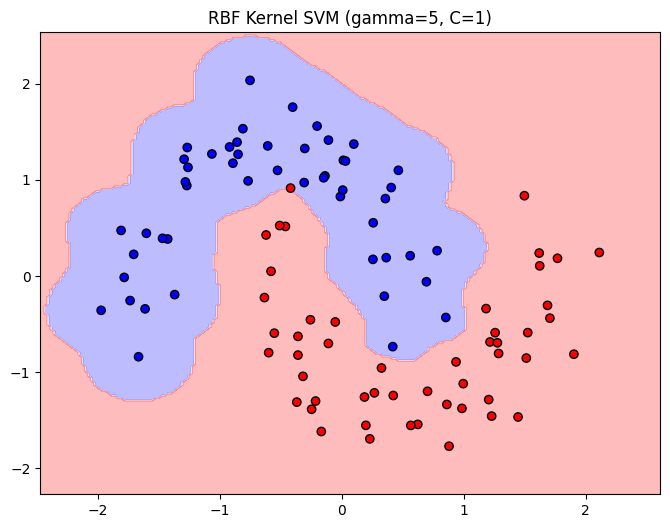

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Moon veri setinin üretilmesi
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# RBF Kernel SVM modelinin kurulması
rbf_kernel_svm = SVC(kernel="rbf", gamma=20, C=100.0)
rbf_kernel_svm.fit(X_scaled, y)

# Karar sınırının görselleştirilmesi
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = rbf_kernel_svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title("RBF Kernel SVM (gamma=5, C=1)")
plt.show()